In [25]:
import polars as pl

# Configure Polars so Jupyter shows ALL columns and a controlled
# number of rows. This prevents truncation and keeps rendering fast.

pl.Config.set_tbl_cols(-1)   # show all columns, no matter how many
pl.Config.set_tbl_rows(10)   # show only 10 rows in the HTML output

# Load the unified tract-quarter feature dataset
df = pl.read_parquet("../../data/processed/feature_engineering/tract_quarter_features.parquet")

# Basic distribution and summary stats
df.select([
    pl.col("reliability_index")
]).describe()


statistic,reliability_index
str,f64
"""count""",10589.0
"""null_count""",0.0
"""mean""",48.43149
"""std""",24.729021
"""min""",0.0
"""25%""",32.229518
"""50%""",46.844152
"""75%""",61.365464
"""max""",100.0


In [26]:
print(df.shape)

(10589, 596)


Matplotlib is building the font cache; this may take a moment.


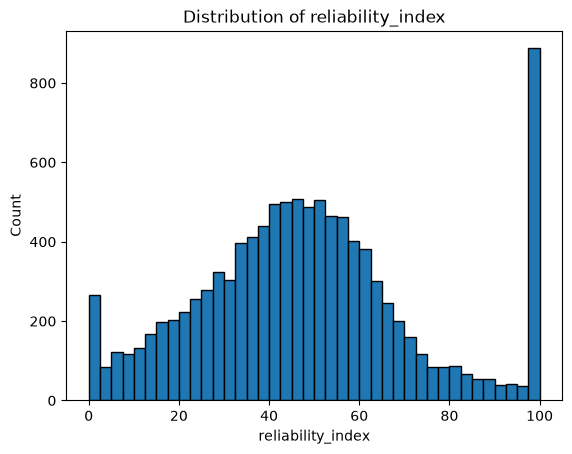

In [11]:
import matplotlib.pyplot as plt

plt.hist(df["reliability_index"], bins=40, edgecolor="black")
plt.title("Distribution of reliability_index")
plt.xlabel("reliability_index")
plt.ylabel("Count")
plt.show()


In [29]:
df.filter(pl.col("reliability_index") == 100).select(pl.col("tests_total")).describe()


statistic,tests_total
str,f64
"""count""",845.0
"""null_count""",0.0
"""mean""",102.72071
"""std""",103.976142
"""min""",1.0
"""25%""",38.0
"""50%""",78.0
"""75%""",137.0
"""max""",1268.0


In [34]:
df.filter(pl.col("reliability_index") == 100).select(pl.col("devices_total")).describe()

statistic,devices_total
str,f64
"""count""",845.0
"""null_count""",0.0
"""mean""",31.656805
"""std""",22.0697
"""min""",1.0
"""25%""",14.0
"""50%""",28.0
"""75%""",43.0
"""max""",115.0


In [30]:
df.filter(pl.col("reliability_index") == 100).select(pl.col("tile_count")).describe()


statistic,tile_count
str,f64
"""count""",845.0
"""null_count""",0.0
"""mean""",4.123077
"""std""",2.732376
"""min""",1.0
"""25%""",2.0
"""50%""",4.0
"""75%""",5.0
"""max""",15.0


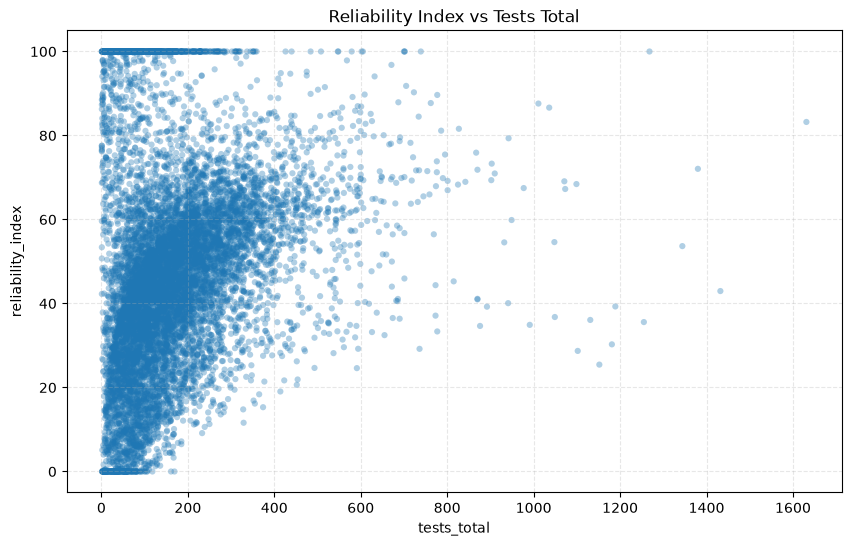

In [31]:
plt.figure(figsize=(10, 6))
plt.scatter(
    df["tests_total"],
    df["reliability_index"],
    alpha=0.35,
    s=20,
    edgecolor="none"
)

plt.title("Reliability Index vs Tests Total")
plt.xlabel("tests_total")
plt.ylabel("reliability_index")
plt.grid(True, linestyle="--", alpha=0.3)
plt.show()

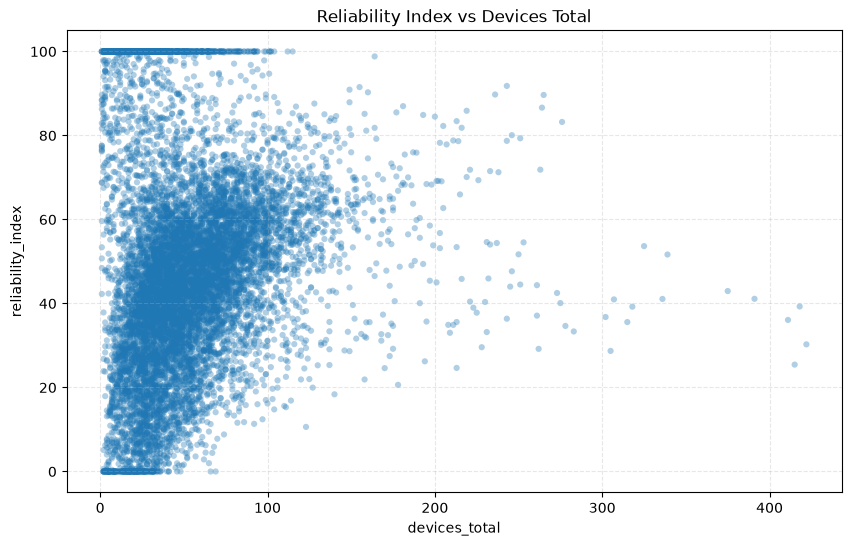

In [32]:
plt.figure(figsize=(10, 6))
plt.scatter(
    df["devices_total"],
    df["reliability_index"],
    alpha=0.35,
    s=20,
    edgecolor="none"
)

plt.title("Reliability Index vs Devices Total")
plt.xlabel("devices_total")
plt.ylabel("reliability_index")
plt.grid(True, linestyle="--", alpha=0.3)
plt.show()

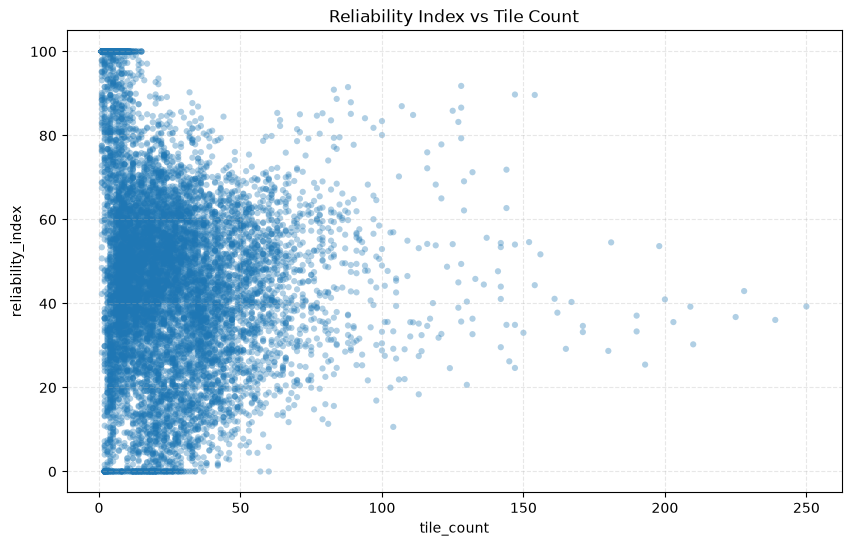

In [33]:
plt.figure(figsize=(10, 6))
plt.scatter(
    df["tile_count"],
    df["reliability_index"],
    alpha=0.35,
    s=20,
    edgecolor="none"
)

plt.title("Reliability Index vs Tile Count")
plt.xlabel("tile_count")
plt.ylabel("reliability_index")
plt.grid(True, linestyle="--", alpha=0.3)
plt.show()

In [13]:
# Quarterly Patterns
df.group_by("quarter").agg(
    pl.mean("reliability_index").alias("mean_reliability"),
    pl.median("reliability_index").alias("median_reliability"),
    pl.std("reliability_index").alias("std_reliability")
).sort("quarter")


quarter,mean_reliability,median_reliability,std_reliability
str,f64,f64,f64
"""Q1""",47.158565,45.523378,25.562722
"""Q2""",47.556319,45.723726,24.306729
"""Q3""",49.52571,47.526099,24.289898
"""Q4""",50.544231,50.297994,24.528535


In [14]:
# Year-over-year patterns
df.group_by("year").agg(
    pl.mean("reliability_index").alias("mean_reliability"),
    pl.median("reliability_index").alias("median_reliability"),
    pl.std("reliability_index").alias("std_reliability")
).sort("year")


year,mean_reliability,median_reliability,std_reliability
i32,f64,f64,f64
2024,48.434725,46.433198,25.561393
2025,48.427179,47.313958,23.576701


In [15]:
# Tract-level variance (reliability stability)
tract_var = df.group_by("tract").agg(
    pl.var("reliability_index").alias("reliability_var"),
    pl.mean("reliability_index").alias("reliability_mean")
).sort("reliability_var", descending=True)

tract_var


tract,reliability_var,reliability_mean
str,f64,f64
"""55101980000""",null,100.0
"""55079009700""",2514.588347,59.909544
"""55079006600""",2361.898,65.33148
"""55079186400""",2352.692252,52.217516
"""55079006000""",2163.529155,69.348786
…,…,…
"""55079091000""",0.0,100.0
"""55079091400""",0.0,100.0
"""55079007800""",0.0,100.0


In [16]:
# Detect outliers
q1 = df["reliability_index"].quantile(0.25)
q3 = df["reliability_index"].quantile(0.75)
iqr = q3 - q1

lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

outliers = df.filter(
    (pl.col("reliability_index") < lower) |
    (pl.col("reliability_index") > upper)
)

outliers


tract,year,quarter,weighted_dry_bulb_temp_mean,weighted_dry_bulb_temp_median,weighted_dry_bulb_temp_std,weighted_dry_bulb_temp_min,weighted_dry_bulb_temp_max,weighted_dry_bulb_temp_range,weighted_dry_bulb_temp_cv,weighted_dry_bulb_temp_p10,weighted_dry_bulb_temp_p25,weighted_dry_bulb_temp_p75,weighted_dry_bulb_temp_p90,weighted_dry_bulb_temp_bucket_-999_0_hours,weighted_dry_bulb_temp_bucket_-999_0_prop,weighted_dry_bulb_temp_bucket_0_10_hours,weighted_dry_bulb_temp_bucket_0_10_prop,weighted_dry_bulb_temp_bucket_10_20_hours,weighted_dry_bulb_temp_bucket_10_20_prop,weighted_dry_bulb_temp_bucket_20_30_hours,weighted_dry_bulb_temp_bucket_20_30_prop,weighted_dry_bulb_temp_bucket_30_40_hours,weighted_dry_bulb_temp_bucket_30_40_prop,weighted_dry_bulb_temp_bucket_40_50_hours,weighted_dry_bulb_temp_bucket_40_50_prop,weighted_dry_bulb_temp_bucket_50_60_hours,weighted_dry_bulb_temp_bucket_50_60_prop,weighted_dry_bulb_temp_bucket_60_70_hours,weighted_dry_bulb_temp_bucket_60_70_prop,weighted_dry_bulb_temp_bucket_70_80_hours,weighted_dry_bulb_temp_bucket_70_80_prop,weighted_dry_bulb_temp_bucket_80_999_hours,weighted_dry_bulb_temp_bucket_80_999_prop,weighted_wet_bulb_temp_mean,weighted_wet_bulb_temp_median,weighted_wet_bulb_temp_std,weighted_wet_bulb_temp_min,weighted_wet_bulb_temp_max,weighted_wet_bulb_temp_range,weighted_wet_bulb_temp_cv,weighted_wet_bulb_temp_p10,weighted_wet_bulb_temp_p25,weighted_wet_bulb_temp_p75,weighted_wet_bulb_temp_p90,weighted_wet_bulb_temp_bucket_-999_0_hours,weighted_wet_bulb_temp_bucket_-999_0_prop,weighted_wet_bulb_temp_bucket_0_10_hours,weighted_wet_bulb_temp_bucket_0_10_prop,weighted_wet_bulb_temp_bucket_10_20_hours,weighted_wet_bulb_temp_bucket_10_20_prop,weighted_wet_bulb_temp_bucket_20_30_hours,weighted_wet_bulb_temp_bucket_20_30_prop,weighted_wet_bulb_temp_bucket_30_40_hours,weighted_wet_bulb_temp_bucket_30_40_prop,weighted_wet_bulb_temp_bucket_40_50_hours,weighted_wet_bulb_temp_bucket_40_50_prop,weighted_wet_bulb_temp_bucket_50_60_hours,weighted_wet_bulb_temp_bucket_50_60_prop,weighted_wet_bulb_temp_bucket_60_70_hours,weighted_wet_bulb_temp_bucket_60_70_prop,weighted_wet_bulb_temp_bucket_70_80_hours,weighted_wet_bulb_temp_bucket_70_80_prop,weighted_wet_bulb_temp_bucket_80_999_hours,weighted_wet_bulb_temp_bucket_80_999_prop,weighted_dew_point_temp_mean,weighted_dew_point_temp_median,weighted_dew_point_temp_std,weighted_dew_point_temp_min,weighted_dew_point_temp_max,weighted_dew_point_temp_range,weighted_dew_point_temp_cv,weighted_dew_point_temp_p10,weighted_dew_point_temp_p25,weighted_dew_point_temp_p75,weighted_dew_point_temp_p90,weighted_dew_point_temp_bucket_-999_0_hours,weighted_dew_point_temp_bucket_-999_0_prop,weighted_dew_point_temp_bucket_0_10_hours,weighted_dew_point_temp_bucket_0_10_prop,weighted_dew_point_temp_bucket_10_20_hours,weighted_dew_point_temp_bucket_10_20_prop,weighted_dew_point_temp_bucket_20_30_hours,weighted_dew_point_temp_bucket_20_30_prop,weighted_dew_point_temp_bucket_30_40_hours,weighted_dew_point_temp_bucket_30_40_prop,weighted_dew_point_temp_bucket_40_50_hours,weighted_dew_point_temp_bucket_40_50_prop,weighted_dew_point_temp_bucket_50_60_hours,weighted_dew_point_temp_bucket_50_60_prop,weighted_dew_point_temp_bucket_60_70_hours,weighted_dew_point_temp_bucket_60_70_prop,weighted_dew_point_temp_bucket_70_80_hours,weighted_dew_point_temp_bucket_70_80_prop,weighted_dew_point_temp_bucket_80_999_hours,weighted_dew_point_temp_bucket_80_999_prop,weighted_relative_humidity_mean,weighted_relative_humidity_median,weighted_relative_humidity_std,weighted_relative_humidity_min,weighted_relative_humidity_max,weighted_relative_humidity_range,weighted_relative_humidity_cv,weighted_relative_humidity_p10,weighted_relative_humidity_p25,weighted_relative_humidity_p75,weighted_relative_humidity_p90,weighted_relative_humidity_bucket_0_30_hours,weighted_relative_humidity_bucket_0_30_prop,weighted_relative_humidity_bucket_30_50_hours,weighted_relative_humidity_bucket_30_50_prop,weighted_relative_humi

In [27]:
# Reliability vs Test Count (quality relationship)
df.select([
    pl.corr("reliability_index", "tests_total").alias("corr_test"),
    pl.corr("reliability_index", "devices_total").alias("corr_device"),
    pl.corr("reliability_index", "tile_count").alias("corr_tile")
])


corr_test,corr_device,corr_tile
f64,f64,f64
0.201018,0.13066,-0.208278


In [ ]:
# Reliability clustering
import numpy as np
from sklearn.cluster import KMeans

X = df["reliability_index"].to_list()
X = np.array(X).reshape(-1, 1)


kmeans = KMeans(n_clusters=4, random_state=42).fit(X)
df = df.with_columns(
    pl.Series("reliability_cluster", kmeans.labels_)
)

df.group_by("reliability_cluster").agg(
    pl.mean("reliability_index"),
    pl.len()
)


C:\Users\brett\AppData\Local\Temp\ipykernel_27848\4291428625.py:16: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  pl.count()


reliability_cluster,reliability_index,count
i32,f64,u32
2,60.029228,3336
3,15.258121,2052
1,39.728765,3853
0,95.103078,1348


In [24]:
# Reliability heatmap by quarter, year
pivot = (
    df.pivot(
        values="reliability_index",
        index="year",
        on="quarter",
        aggregate_function="mean",
        sort_columns=True
    ).sort("year")
)

pivot


year,Q1,Q2,Q3,Q4
i32,f64,f64,f64,f64
2024,47.895632,47.018312,48.282018,50.544231
2025,46.421986,48.09397,50.770224,null
